### Using the HadISD datset (version 3.4.0.2023f) with PyEarthTools
HadISD is a global sub-daily dataset based on the ISD dataset from NOAA's NCEI. As well as station selection criteria, a suite of quality control tests has been run on the major climatological variables.

The dataset can be downloaded here: https://www.metoffice.gov.uk/hadobs/hadisd/v340_2023f/download.html

In [1]:
import datetime
from pathlib import Path

import pyearthtools.pipeline as petpipe
import pyearthtools.data as petdata
from pyearthtools.tutorial.HadisdDataClass import HadISDIndex

# Create an ordered list of all available HadISD station IDs
The  HadISDIndex class contains a method called "get_alL station_ids" that can be used to create a list of all available station IDS This list can be passed directly to the HadISD filesystem method. It's also possible to pass a single station ID as a string to retrieve data for a single station.

TODO:

- Ideally the list is created on the fly when the string "all" is passed to the accessor, but there is a flaw that means this doesn't work yet.
- It would also be good if a range of stations can be provided, or a boundary with stations inside

In [2]:
hadisd = HadISDIndex()
all_stations = hadisd.get_all_station_ids(Path("/Users/joelmiller/Projects/data/hadisd"))
all_stations_ordered = sorted(all_stations)
print(f"Total number of stations: {len(all_stations_ordered)}")
first_ten = all_stations_ordered[:10]
print(first_ten)

Total number of stations: 1529
['010010-99999', '010014-99999', '010030-99999', '010070-99999', '010080-99999', '010100-99999', '010150-99999', '010230-99999', '010250-99999', '010260-99999']


In [3]:
varname_val_map = {
        "total_cloud_cover": -999., 
        "low_cloud_cover": -999., 
        "mid_cloud_cover": -999.,
        "high_cloud_cover": -999.
    }

flagged_labels = [
        'temperatures', 'dewpoints', 'slp',
        'stnlp', 'windspeeds', 'winddirs', 
        'total_cloud_cover', 'low_cloud_cover', 'mid_cloud_cover', 
        'high_cloud_cover', 'precip1_depth', 'precip2_depth', 
        'precip3_depth', 'precip6_depth', 'precip9_depth',
        'precip12_depth', 'precip15_depth', 'precip18_depth', 
        'precip24_depth'
    ]

# Pipeline Definition

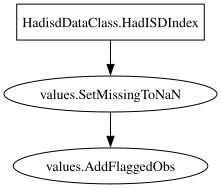

In [6]:
data_prep_pipe = petpipe.Pipeline(
    petdata.archive.hadisd(first_ten), # , variables = ["total_cloud_cover", "temperatures", "flagged_obs"]), # Commented out variable selection whilst looking into bug in BaseTransforms
    # petdata.transforms.variables.SelectVariables(variables=["total_cloud_cover", "temperatures", "flagged_obs"]), # Use transform in pipeline to bypass bug in BaseTransforms
    # petdata.transforms.variables.Drop("reporting_stats"),
    petdata.transforms.values.SetMissingToNaN(varname_val_map),
    petdata.transforms.values.AddFlaggedObs(flagged_labels),
    #petdata.transofmrs.derive.WetBulbTemp(), # Should probably be in a separate pipeline where heavier processing is done
)
data_prep_pipe

In [7]:
ds = data_prep_pipe["1970-01-01T06"]
ds

<xarray.Dataset> Size: 3MB
Dimensions:                (time: 1, station: 10, flagged: 19, test: 71,
                            reporting_v: 19, reporting_t: 1116, reporting_2: 2,
                            coordinate_length: 1)
Coordinates:
    elevation              (station, coordinate_length) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    latitude               (station, coordinate_length) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    longitude              (station, coordinate_length) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    station_id             (station) <U12 480B '010010-99999' ... '010260-99999'
  * time                   (time) datetime64[ns] 8B 1970-01-01T06:00:00
  * flagged                (flagged) <U17 1kB 'temperatures' ... 'precip24_de...
Dimensions without coordinates: station, test, reporting_v, reporting_t,
                                reporting_2, coordinate_length
Data variables: (12/25)
    cloud_base             (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    dewpoints              (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    flagged_obs            (time, station, flagged) float64 2kB dask.array<chunksize=(1, 1, 3), meta=np.ndarray>
    high_cloud_cover       (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    low_cloud_cover        (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    mid_cloud_cover        (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    ...                     ...
    stnlp                  (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    temperatures           (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    total_cloud_cover      (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    wind_gust              (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    winddirs               (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    windspeeds             (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
Attributes: (12/39)
    Conventions:                 CF-1.6
    Metadata_Conventions:        Unidata Dataset Discovery v1.0, CF Discrete ...
    acknowledgement:             RJHD was supported by the Joint BEIS/Defra M...
    cdm_data_type:               station
    creator_email:               robert.dunn@metoffice.gov.uk
    creator_name:                Robert Dunn
    ...                          ...
    station_id:                  010010-99999
    station_information:         Where station is a composite the station id ...
    summary:                     Quality-controlled, sub-daily, station datas...
    time_coverage_end:           2023-12-31T23:00Z
    time_coverage_start:         1931-01-01T06:00Z
    title:                       HadISD

In [ ]:
for coord in ["latitude", "longitude", "elevation"]:
    if coord in ds:
        ds = ds.set_coords(coord)
ds

In [ ]:
for coord in ["latitude", "longitude", "elevation"]:
    if coord in ds.coords and "coordinate_length" in ds[coord].dims:
        ds[coord] = ds[coord].squeeze("coordinate_length")

ds

In [ ]:
for coord in ["latitude", "longitude", "elevation"]:
    if coord in ds:
        ds = ds.set_coords(coord)

ds

In [8]:
import pyearthtools.data as petdata
# select only total_cloud_cover
ds_all_tcc = ds.pipe(petdata.transforms.variables.Select("total_cloud_cover", "dewpoints", "temperatures", "flagged_obs"))
ds_all_tcc

<xarray.Dataset> Size: 4kB
Dimensions:            (time: 1, station: 10, flagged: 19)
Coordinates:
    station_id         (station) <U12 480B '010010-99999' ... '010260-99999'
  * time               (time) datetime64[ns] 8B 1970-01-01T06:00:00
  * flagged            (flagged) <U17 1kB 'temperatures' ... 'precip24_depth'
Dimensions without coordinates: station
Data variables:
    dewpoints          (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    total_cloud_cover  (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    temperatures       (time, station) float64 80B dask.array<chunksize=(1, 1), meta=np.ndarray>
    flagged_obs        (time, station, flagged) float64 2kB dask.array<chunksize=(1, 1, 3), meta=np.ndarray>
Attributes: (12/39)
    Conventions:                 CF-1.6
    Metadata_Conventions:        Unidata Dataset Discovery v1.0, CF Discrete ...
    acknowledgement:             RJHD was supported by the Joint BEIS/Defra M...
    cdm_data_type:               station
    creator_email:               robert.dunn@metoffice.gov.uk
    creator_name:                Robert Dunn
    ...                          ...
    station_id:                  010010-99999
    station_information:         Where station is a composite the station id ...
    summary:                     Quality-controlled, sub-daily, station datas...
    time_coverage_end:           2023-12-31T23:00Z
    time_coverage_start:         1931-01-01T06:00Z
    title:                       HadISD

In [ ]:
# Show the lat and lon coordinatesfor the first station
print(f"Latitude: {ds.latitude.values[1]}")
print(f"Longitude: {ds.longitude.values[1]}")




# Notes:
- Dropping variables results in coordinates being dropped, which is not what we want.
- Calculating wetbulb temps for just 10 stations takes a very long time; therefore, 
  I wonder if it is best suited to a separate pre-processing pipeline to get the data into a more suitable format ready for manipulations to be done.
- Don't know what combination of stations you want when selecting nearest neighbours, so want to cahce on a per-station basis. This might be differnt with zarr.

TODO:
- Change preprocessing so that coordinates are not dropped when dropping or selecting variables.

In some cases you will get the following error when passing a date time to a pipeline object: `IndexWarning: Could not find time in dataset to select on. Petdt('1931-01-01T07')`<br>

This indicates that data for the datetime you chose does not exist. In this case PET will load all data from your station selection.

In [ ]:
# show total_cloud_cover from ds
tcc = ds["total_cloud_cover"]
tcc

# For specific Stations

In [ ]:
from pyearthtools.tutorial.HadisdDataClass import HadISDIndex
from pathlib import Path
hadisd = HadISDIndex(["010014-99999", "010010-99999", "010030-99999"])
paths = hadisd.filesystem()
paths


In [ ]:
file_paths = list(paths.values())
file_paths

In [ ]:
ds = hadisd.load(file_paths)
ds

# For all stations

In [ ]:
hadisd = HadISDIndex("all")

all_station_ids = hadisd.get_all_station_ids(Path("/Users/joelmiller/Projects/data/hadisd"))
print(all_station_ids[:10])
print(len(all_station_ids))


In [ ]:
hadisd = HadISDIndex(all_station_ids)
paths = hadisd.filesystem() 
paths = list(paths.values())

In [ ]:
ds_all = hadisd.load(paths)
ds_all

In [ ]:
import pyearthtools.data as petdata
# select only total_cloud_cover
ds_all_tcc = ds_all.pipe(petdata.transforms.variables.Select("total_cloud_cover"))
ds_all_tcc


In [ ]:
# Manuall apply the transform
varname_val_map = {
        "total_cloud_cover": -999., 
        "low_cloud_cover": -999., 
        "mid_cloud_cover": -999.,
        "high_cloud_cover": -999.
    }

ds_all_tcc_nan = ds_all.pipe(petdata.transforms.values.SetMissingToNaN(varname_val_map))
ds_all_tcc_nan

In [ ]:
tcc = ds_all["total_cloud_cover"]
tcc

# Stuff in this section is not used in the tutorial, but is useful for testing and exploration

In [ ]:

# I think used for preprocessing to zarr?
date_range=(datetime.datetime(1986,11,20,12,0), datetime.datetime(1986,11,21,0,0))

In [ ]:
varname_val_map = {
        "total_cloud_cover": -999., 
        "low_cloud_cover": -999., 
        "mid_cloud_cover": -999.,
        "high_cloud_cover": -999.
    }

# Probably sensible to accetp a list since some variables might have multiple values
# This would look like:
# varname_val_map = {
#         "total_cloud_cover": [-888., -999.],
#         "low_cloud_cover": [-888., -999.],
#         "mid_cloud_cover": [-999.],
#         "high_cloud_cover": [-999.]
#     }

In [ ]:
# train/validation/test split dates
train_start = "1970-01-01T00"
train_end = "2022-12-31T23"

In [ ]:
data_prep_pipe = petpipe.Pipeline(
    # petdata.archive.hadisd(("010010-99999"), variables = ["total_cloud_cover", "temperatures", "flagged_obs"]),
    # petdata.archive.hadisd(station = ["010014-99999"], variables = ["total_cloud_cover", "temperatures", "flagged_obs"]),
    
    # Current options for indexing
    #petdata.archive.hadisd(["010014-99999", "010010-99999", "010030-99999"]),    
    petdata.archive.hadisd("010010-99999", variables=["total_cloud_cover", "temperatures", "flagged_obs"]),

    petdata.transforms.values.AddFlaggedObs(flagged_labels),
    petdata.transforms.values.SetMissingToNaN(varname_val_map),
    
    # Possible ways of indexing in the future:
    # petdata.archive.hadisd(country_code = "24", station_id = "010010", nearest_neighbors = 12, lon= 0.0, lat = 0.0), # Geospatial fence 
    # petdata.archive.hadisd("010014-99999"), # Geospatial fence
)
data_prep_pipe

# Don't know what combination of stations you want when selecting nearest neighbours, so want to cahce on a per-station basis

# Use the section below to build tests to check that all pipeline steps are working as expected

## Test SetMissingToNaN

In [ ]:
import xarray as xr
from pyearthtools.data.transforms.values import SetMissingToNaN
import numpy as np

def test_set_missing_to_nan():
    data = xr.Dataset({
        "total_cloud_cover": ("time", [0, -999, 50]),
        "low_cloud_cover": ("time", [10, -999, 20]),
    })

    varname_val_map = {
        "total_cloud_cover": -99.0,
        "low_cloud_cover": -999.0,
    }

    transform = SetMissingToNaN(varname_val_map)
    transformed_data = transform.apply(data)

    if np.isnan(transformed_data["total_cloud_cover"].data[1]):
        print("Total cloud cover at index 1 is NaN")
    else:
        print("Total cloud cover at index 1 is not NaN")
    
    if np.isnan(transformed_data["low_cloud_cover"].data[1]):
        print("Low cloud cover at index 1 is NaN")
    
    if transformed_data["total_cloud_cover"].data[2] == 50:
        print("Total cloud cover at index 2 is 50")

In [ ]:
test_set_missing_to_nan()

## Test AddFlaggedObs

In [ ]:
import xarray as xr
import numpy as np
from pyearthtools.data.transforms.values import AddFlaggedObs

def test_add_flagged_obs():
    # Mock dataset with flagged observations
    data = xr.Dataset(
        {
            "temperatures": (("time",), [np.nan, 15.0, np.nan]),
            "dewpoints": (("time",), [np.nan, 10.0, np.nan]),
            "flagged_obs": (
                ("time", "flagged"),
                [
                    [20.0, np.nan],  # Flagged data for time=0
                    [np.nan, np.nan],  # No flagged data for time=1
                    [25.0, 12.0],  # Flagged data for time=2
                ],
            ),
        },
        coords={
            "time": [0, 1, 2],
            "flagged": [0, 1],  # Indices for flagged variables
        },
    )

    # Add flagged_value attribute to variables
    data["temperatures"].attrs["flagged_value"] = -999.0
    data["dewpoints"].attrs["flagged_value"] = -999.0

    # Define flagged labels corresponding to the flagged dimension
    flagged_labels = ["temperatures", "dewpoints"]

    # Apply the AddFlaggedObs transform
    transform = AddFlaggedObs(flagged_labels)
    transformed_data = transform.apply(data)

    # Assert that flagged data has been restored
    assert np.allclose(
        transformed_data["temperatures"].data, [20.0, 15.0, 25.0], equal_nan=True
    )
    assert np.allclose(
        transformed_data["dewpoints"].data, [np.nan, 10.0, 12.0], equal_nan=True
    )

    print("Test passed: Flagged observations were correctly restored.")

# Run the test
test_add_flagged_obs()